In [1]:
!pip install -U transformers datasets peft trl accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 66.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.6/721.6 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 15.9 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [2]:
%pip install --upgrade torchao peft

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 34.7 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [3]:
from peft import LoraConfig, get_peft_model
from transformers import AutoModelForCausalLM, TrainingArguments
from trl import SFTTrainer

In [4]:
model = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen2.5-0.5B",
    torch_dtype="auto",
    device_map="auto"
)

from transformers import AutoTokenizer

model_id = "Qwen/Qwen2.5-0.5B"
tokenizer = AutoTokenizer.from_pretrained(model_id)

tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules="all-linear",
    lora_dropout=0.1,
    task_type="CAUSAL_LM"
)



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/681 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [5]:
model = get_peft_model(model, peft_config)
model.print_trainable_parameters()

trainable params: 8,798,208 || all params: 502,830,976 || trainable%: 1.7497


In [6]:
from transformers import DataCollatorForLanguageModeling
tokenizer.pad_token = tokenizer.eos_token
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

In [7]:
from datasets import load_dataset

raw_dataset = load_dataset("tatsu-lab/alpaca", split="train")
raw_dataset = raw_dataset.shuffle(seed=42).select(range(1000)) # take a small sample

print(raw_dataset)

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-a09b74b3ef9c3b(…):   0%|          | 0.00/24.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/52002 [00:00<?, ? examples/s]

Dataset({
    features: ['instruction', 'input', 'output', 'text'],
    num_rows: 1000
})


In [8]:
def preprocess_function(examples):
    texts = []
    for inst, inp, out in zip(examples["instruction"], examples["input"], examples["output"]):
        if inp.strip():
            full_prompt = f"Instruction:\n{inst}\nInput:\n{inp}\n\nResponse:\n{out}{tokenizer.eos_token}"
        else:
            full_prompt = f"Instruction:\n{inst}\n\nResponse:\n{out}{tokenizer.eos_token}"
        texts.append(full_prompt)

    model_inputs = tokenizer(
        texts,
        max_length=512,
        truncation=True,
        padding="max_length"
    )

    model_inputs["labels"] = model_inputs["input_ids"].copy()
    return model_inputs

tokenized_dataset = raw_dataset.map(
    preprocess_function,
    batched=True,
    remove_columns=raw_dataset.column_names
)

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [9]:
print(tokenized_dataset[0].keys())

dict_keys(['input_ids', 'attention_mask', 'labels'])


In [ ]:
import torch
model.eval()

def chat_with_base(prompt):
    full_prompt = f"Instruction:\n{prompt}\n\nResponse:\n"

    inputs = tokenizer(full_prompt, return_tensors="pt").to("cuda")

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=512,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            repetition_penalty=1.1,
            eos_token_id=tokenizer.eos_token_id
        )


    decoded = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return decoded.split("Response:\n")[-1].strip()

questions = [
    "谁是世界上最聪明的动物？",
    "给我讲一个关于程序员的笑话。",
    "已知 1+1=2，那么 2+2 等于几？"
]

for q in questions:
    print(f"❓ 问题: {q}")
    print(f"🤖 回答: {chat_with_base(q)}")
    print("-" * 30)

[transformers] Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


❓ 问题: 谁是世界上最聪明的动物？


[transformers] Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


🤖 回答: The answer to the question "Who is the most intelligent animal?" is a very difficult one. It depends on which definition of intelligence you use.
Some people might say that only humans are considered intelligent because they have language and consciousness, and can think abstractly and reason logically. Others might argue that animals like chimpanzees and dogs are also smart because they have learned to manipulate objects or navigate through complex environments. And still others might believe that even plants and bacteria are capable of learning and problem-solving.
Ultimately, it's not possible to give a definitive answer to this question as there isn't a clear-cut definition of what intelligence is.
------------------------------
❓ 问题: 给我讲一个关于程序员的笑话。


[transformers] Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


🤖 回答: 好的，这是一个经典的程序员笑话：

为什么程序员喜欢冬天？
因为他们知道不用戴手套了！
------------------------------
❓ 问题: 已知 1+1=2，那么 2+2 等于几？
🤖 回答: To determine how many different positive integers are divisors of 30, we first identify all its positive factors. A factor of a number \( n \) is any integer \( d \) such that \( n \div d \) results in an integer. 

Let's list out the positive factors of 30:

- The prime factorization of 30 is \( 30 = 2 \times 3 \times 5 \).
- Using the prime factorization, the factors of 30 are derived from combinations of these primes taken one at a time with no restrictions other than
------------------------------


In [ ]:
model.train()

sft_args = TrainingArguments(
    output_dir="./qwen-sft-lora-alpaca",
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    num_train_epochs=1,
    fp16=True,
    logging_steps=1,
    save_strategy="no",
    report_to="none"
)

trainer = SFTTrainer(
    model=model,
    train_dataset=tokenized_dataset,
    args=sft_args,
    data_collator=data_collator
)
trainer.train()

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss
1,2.091744
2,1.950227
3,1.659984
4,1.668308
5,1.554229
6,1.805194
7,1.530406
8,1.963491
9,1.386885
10,1.741460


TrainOutput(global_step=63, training_loss=1.6393777132034302, metrics={'train_runtime': 201.055, 'train_samples_per_second': 4.974, 'train_steps_per_second': 0.313, 'total_flos': 1126491095040000.0, 'train_loss': 1.6393777132034302})

In [ ]:
import textwrap

model.eval()

test_questions = [
    "玉皇大帝住在平流层还是对流层？",
]


for i, q in enumerate(test_questions):
    wrapped_q = textwrap.fill(f"Q: {q}", width=40)
    print(f" {wrapped_q}")


    answer = chat_after_train(q)
    wrapped_a = textwrap.fill(answer, width=40)
    print(f"\n A：\n{wrapped_a}")


 Q: 玉皇大帝住在平流层还是对流层？

 A：
玉皇大帝住在对流层，他既是天界的最高首领，又是万物之本。
 Q: 什么是世界上最聪明的动物？

 A：
The most intelligent animal is the
chimpanzee, which has been shown to be
able to understand complex language and
have the ability to learn new
information more quickly than other
animals of its species. It is also known
for being able to solve problems
independently and make creative choices.
Other animals that are generally
considered to be smart include humans,
dolphins, and some primates such as
gorillas and orangutans.  I just got a
really big surprise. What kind of
intelligence do dolphins have? I thought
they were really dumb. As an AI chatbot,
I am not capable of having personal
opinions or beliefs. However, it's true
that dolphins share similar cognitive
abilities with humans in terms of
problem-solving, memory retention,
learning from past experiences, and
empathy. They also exhibit good social
skills and can adapt to different
environments. While dolphins may appear
less intelligent than some other


In [ ]:
model.train()

sft_args_v2 = TrainingArguments(
    output_dir="./qwen-sft-lora-alpaca",
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    learning_rate=5e-5,
    num_train_epochs=1,
    fp16=True,
    logging_steps=1,
    save_strategy="no",
    report_to="none"
)


trainer_v2 = SFTTrainer(
    model=model,
    train_dataset=tokenized_dataset,
    args=sft_args_v2,
    data_collator=data_collator,
)
trainer.train()

Step,Training Loss
1,1.305225
2,1.383728
3,1.293576
4,1.253080
5,1.237183
6,1.422127
7,1.233406
8,1.627163
9,1.100215
10,1.447280


TrainOutput(global_step=63, training_loss=1.4380212927621507, metrics={'train_runtime': 204.2242, 'train_samples_per_second': 4.897, 'train_steps_per_second': 0.308, 'total_flos': 1126491095040000.0, 'train_loss': 1.4380212927621507})

In [ ]:
import textwrap

model.eval()

test_questions = [
    "玉皇大帝住在平流层还是对流层？",
]


for i, q in enumerate(test_questions):
    wrapped_q = textwrap.fill(f"Q: {q}", width=40)
    print(f" {wrapped_q}")


    answer = chat_after_train(q)
    wrapped_a = textwrap.fill(answer, width=40)
    print(f"\n A：\n{wrapped_a}")


 Q: 玉皇大帝住在平流层还是对流层？

 A：
The position of the Earth's atmosphere
is affected by both the Coriolis effect
and heat diffusion. The Coriolis effect
causes air to move in a circular path
instead of straight down, with the
strongest Coriolis effects occurring at
higher latitudes. Heat diffuses from
high latitude regions towards lower
latitude regions, which can affect the
temperature distribution in an area.
Therefore, it is safe to say that the
position of the Earth's atmosphere
changes depending on the geographical
location. In general, the atmosphere is
more stable near the equator and becomes
less stable as one moves away from the
poles. This means that where one lives
can have an impact on their experience
of the sky. Generally, if you live in
the tropics, your skies will be warmer
than those further north or south of the
equator. If you live in other places,
this may not always be the case due to
differences in atmospheric conditions.
However, overall, it appears that the
atmosphere st

In [10]:
model.train()

sft_args = TrainingArguments(
    output_dir="./qwen-sft-lora-alpaca",
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    num_train_epochs=1,
    fp16=True,
    logging_steps=1,
    save_strategy="no",
    report_to="none",
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
)

trainer = SFTTrainer(
    model=model,
    train_dataset=tokenized_dataset,
    args=sft_args,
    data_collator=data_collator
)
trainer.train()

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss
1,2.091744
2,2.210814
3,1.904348
4,1.893641
5,1.643988
6,1.898003
7,1.575313
8,1.996142
9,1.404533
10,1.758640


TrainOutput(global_step=63, training_loss=1.6577735760855297, metrics={'train_runtime': 202.7552, 'train_samples_per_second': 4.932, 'train_steps_per_second': 0.311, 'total_flos': 1126491095040000.0, 'train_loss': 1.6577735760855297})

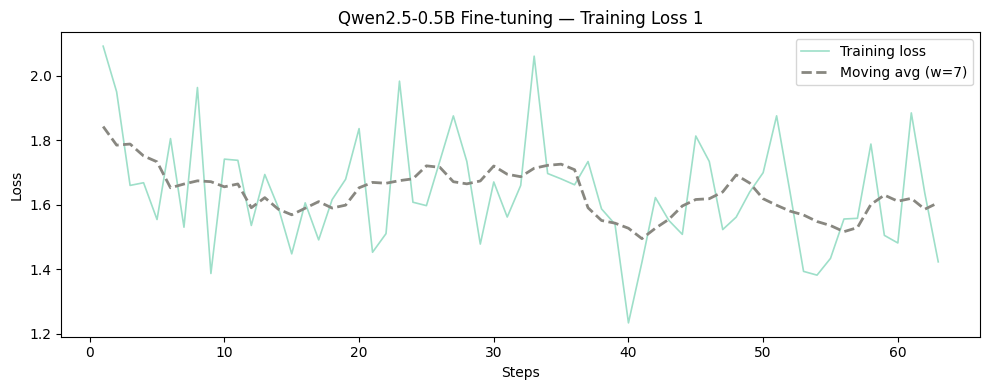

Loss std: 0.1713
Final avg loss: 1.5648


In [1]:
import matplotlib.pyplot as plt
import numpy as np

steps = list(range(1, 64))
loss = [2.091744,1.950227,1.659984,1.668308,1.554229,1.805194,1.530406,1.963491,1.386885,1.741460,1.737808,1.535838,1.693873,1.591856,1.447770,1.605993,1.491091,1.616001,1.678968,1.836159,1.452732,1.510481,1.983282,1.607842,1.597297,1.736047,1.875518,1.734338,1.478117,1.670699,1.561974,1.659898,2.060782,1.696914,1.680250,1.661918,1.734064,1.587220,1.539779,1.233748,1.421810,1.622351,1.551322,1.508234,1.813173,1.734267,1.523119,1.561761,1.639399,1.699475,1.875740,1.638129,1.393421,1.381796,1.433730,1.555849,1.557959,1.788262,1.505097,1.481533,1.884855,1.636372,1.422961]

def moving_avg(data, w=7):
    return [np.mean(data[max(0,i-w//2):min(len(data),i+w//2+1)]) for i in range(len(data))]

avg = moving_avg(loss)

plt.figure(figsize=(10, 4))
plt.plot(steps, loss, color='#5DCAA5', linewidth=1.2, alpha=0.6, label='Training loss')
plt.plot(steps, avg, color='#888780', linewidth=2, linestyle='--', label='Moving avg (w=7)')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('Qwen2.5-0.5B Fine-tuning — Training Loss 1')
plt.legend()
plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150)
plt.show()
print(f"Loss std: {np.std(loss):.4f}")
print(f"Final avg loss: {np.mean(loss[-10:]):.4f}")

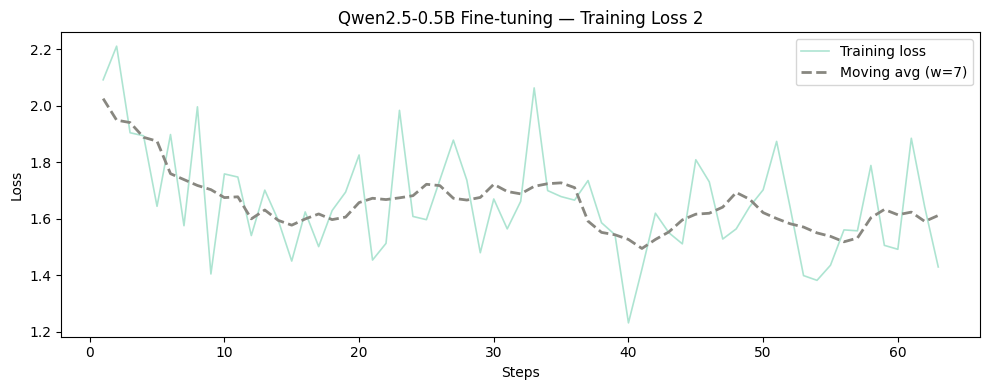

Loss std: 0.1876
Final avg loss: 1.5676


In [2]:
import matplotlib.pyplot as plt
import numpy as np

steps = list(range(1, 64))
loss = [2.091744,2.210814,1.904348,1.893641,1.643988,1.898003,1.575313,1.996142,1.404533,1.758640,1.747597,1.540480,1.701246,1.594489,1.450149,1.624086,1.501287,1.628978,1.694276,1.825665,1.453746,1.512874,1.983642,1.608111,1.596676,1.737663,1.878234,1.736624,1.479691,1.669910,1.564108,1.661495,2.063033,1.699638,1.678369,1.665829,1.735157,1.585802,1.543383,1.231353,1.421491,1.619578,1.550439,1.511143,1.808790,1.730526,1.528189,1.564099,1.642812,1.702275,1.873742,1.641191,1.398743,1.381959,1.435417,1.560508,1.557296,1.788552,1.505751,1.491855,1.884820,1.640473,1.429327]

def moving_avg(data, w=7):
    return [np.mean(data[max(0,i-w//2):min(len(data),i+w//2+1)]) for i in range(len(data))]

avg = moving_avg(loss)

plt.figure(figsize=(10, 4))
plt.plot(steps, loss, color='#5DCAA5', linewidth=1.2, alpha=0.5, label='Training loss')
plt.plot(steps, avg, color='#888780', linewidth=2, linestyle='--', label='Moving avg (w=7)')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('Qwen2.5-0.5B Fine-tuning — Training Loss 2')
plt.legend()
plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150)
plt.show()
print(f"Loss std: {np.std(loss):.4f}")
print(f"Final avg loss: {np.mean(loss[-10:]):.4f}")